# BridgeData V2 - Frame Loading & Scene Filtering


Streams BridgeData V2 episodes from the public GCS mirror, extracts initial
frames, instructions and early-motion ground truth, filters to multi-object /
spatial scenes via a text heuristic, and caches the survivors to Drive.

Each cached scene also gets a second, grasp-frame observation when the source
episode closes its gripper: the step where a `placement_relation` instruction's
two antonym-swapped variants first demand different behaviour. See
`docs/PROBE_AND_ANALYSIS.md` for the two-frame protocol this feeds.

This notebook uses only the TensorFlow/TFDS stack. The model is never loaded
here. 


## 0. Dependencies

TensorFlow Datasets (through `tensorflow-metadata`) and current TensorFlow are
compiled against protobuf 6 and require `protobuf>=6.31.1`. A managed runtime
that still ships an older protobuf 5 runtime raises a `VersionError` the moment
TFDS is imported. The cell below upgrades the protobuf runtime when needed. If it
performs an install, restart the session (Runtime, Restart session) once and
re-run from here before streaming.

In [1]:
import subprocess, sys
import google.protobuf as _pb

_major, _minor = (int(x) for x in _pb.__version__.split('.')[:2])
if (_major, _minor) < (6, 31):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'protobuf>=6.31.1,<7'], check=True)
    print(f'protobuf {_pb.__version__} upgraded to >=6.31.1. Restart the runtime '
          '(Runtime > Restart session), then re-run from this cell.')
else:
    print(f'protobuf {_pb.__version__} OK')

protobuf 7.35.1 OK


## 1. Mount Drive 

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
CACHE_DIR = '/content/drive/MyDrive/openvla_cache/bridge_multiobj'
os.makedirs(CACHE_DIR, exist_ok=True)
print('cache ->', CACHE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cache -> /content/drive/MyDrive/openvla_cache/bridge_multiobj


## 2. Import `data.py`

Clones the project code from GitHub into the runtime and imports the loader,
inference, and logging functions from there, so the code always matches the
pushed commit.


In [3]:
import sys, os, importlib, subprocess

REPO_URL = 'https://github.com/LewisTL/ECS8056.git'
BRANCH = 'master'
REPO_DIR = '/content/ECS8056'

def sync_repo():
    """Clone or hard-refresh the repository so it matches origin/BRANCH."""
    token = os.environ.get('GITHUB_TOKEN', '')
    url = REPO_URL.replace('https://', f'https://{token}@') if token else REPO_URL
    if os.path.isdir(os.path.join(REPO_DIR, '.git')):
        subprocess.run(['git', '-C', REPO_DIR, 'remote', 'set-url', 'origin', url],
                       check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'fetch', '--quiet', '--depth', '1',
                        'origin', BRANCH], check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', '--quiet',
                        f'origin/{BRANCH}'], check=True)
    else:
        subprocess.run(['git', 'clone', '--quiet', '--depth', '1', '--branch',
                        BRANCH, url, REPO_DIR], check=True)
    return subprocess.run(['git', '-C', REPO_DIR, 'rev-parse', '--short', 'HEAD'],
                          capture_output=True, text=True).stdout.strip()


commit = sync_repo()
module_dir = REPO_DIR
if module_dir not in sys.path:
    sys.path.insert(0, module_dir)
for _m in ('model', 'data', 'export_pairs', 'detect_duplicates'):
    sys.modules.pop(_m, None)
importlib.invalidate_caches()

import data
from data import (stream_episodes, classify_instruction, cache_records,
                  load_manifest)
print(f'imported data.py from {module_dir} @ {commit}')


imported data.py from /content/ECS8056 @ 8d4a819


## 3. Stream a small slice and inspect extraction

Pulls a handful of episodes to confirm the keys resolve and the early-motion
ground truth is non-zero (the first transition is a recorded no-op and is
skipped).


In [4]:
import numpy as np
sample = list(stream_episodes(n=8))
for r in sample:
    g = r.grasp_frame_index if r.grasp_frame_index is not None else '-'
    print(f'ep {r.episode_index:>5} | steps={r.num_steps:>3} | grasp={g!s:>3} | '
          f'gt_xyz={np.round(r.gt_vector[:3], 4)} | {r.instruction}')

ep     0 | steps= 38 | grasp=  - | gt_xyz=[-0.0868  0.0915 -0.0258] | Place the can to the left of the pot.
ep     1 | steps= 32 | grasp=  7 | gt_xyz=[ 0.0585  0.0423 -0.044 ] | Move the silver pot from in front of the red can, to next to the blue towel at the front edge of the table.
ep     2 | steps= 32 | grasp=  - | gt_xyz=[-0.0676 -0.0769  0.0369] | Slide the cloth diagonally to the front of the spoon
ep     3 | steps= 22 | grasp=  8 | gt_xyz=[ 0.0084  0.0017 -0.0229] | put knife on cutting board
ep     4 | steps= 48 | grasp= 16 | gt_xyz=[-0.063   0.1333 -0.0066] | Move the kadai and place it at the right edge of the table.
ep     5 | steps= 27 | grasp=  8 | gt_xyz=[-0.069 -0.036 -0.06 ] | Put the banana on the green cloth
ep     6 | steps= 32 | grasp=  - | gt_xyz=[ 0.068  -0.1475 -0.0065] | Put the napkin in the bottom right hand corner of the table.
ep     7 | steps= 47 | grasp= 13 | gt_xyz=[-0.0772 -0.1022  0.0064] | place the silver pot on the yellow napkin


## 4. Filter yield on the slice

Reports how the text heuristic tags the sampled instructions. `has_spatial` is
the primary probe target; `has_transfer` is the broader multi-object pool.


In [5]:
for r in sample:
    t = r.tags
    print(f'multi={t.is_multi_object!s:5} spatial={t.has_spatial!s:5} '
          f'transfer={t.has_transfer!s:5} [{t.matched or "-"}] {r.instruction}')

multi=True  spatial=True  transfer=False [left|to the left] Place the can to the left of the pot.
multi=True  spatial=True  transfer=True  [front|next to|in front of|transfer] Move the silver pot from in front of the red can, to next to the blue towel at the front edge of the table.
multi=True  spatial=True  transfer=False [front] Slide the cloth diagonally to the front of the spoon
multi=True  spatial=False transfer=True  [transfer] put knife on cutting board
multi=True  spatial=True  transfer=False [right] Move the kadai and place it at the right edge of the table.
multi=True  spatial=False transfer=True  [transfer] Put the banana on the green cloth
multi=True  spatial=True  transfer=True  [bottom|right|transfer] Put the napkin in the bottom right hand corner of the table.
multi=True  spatial=False transfer=True  [transfer] place the silver pot on the yellow napkin


## 5. Multi-object yield over a larger slice

Scales the stream up to estimate how many candidate scenes BridgeData V2 yields.
Raise `N` for a tighter estimate. Streaming is sequential so larger N is slower.
A low spatial yield here is the early signal to supplement with the Open
X-Embodiment subset held in reserve.


In [6]:
N = 300   # scale up/down as session time allows
counts = {'total': 0, 'multi': 0, 'spatial': 0, 'transfer': 0}
survivors = []
for r in stream_episodes(n=N):
    counts['total'] += 1
    if r.tags.is_multi_object: counts['multi'] += 1; survivors.append(r)
    if r.tags.has_spatial:     counts['spatial'] += 1
    if r.tags.has_transfer:    counts['transfer'] += 1

print(counts)
print(f"multi-object: {counts['multi']/counts['total']:.1%} | "
      f"spatial: {counts['spatial']/counts['total']:.1%} | "
      f"transfer: {counts['transfer']/counts['total']:.1%}")

{'total': 300, 'multi': 224, 'spatial': 119, 'transfer': 140}
multi-object: 74.7% | spatial: 39.7% | transfer: 46.7%


## 6. Cache survivors to Drive

Persists only the filtered frames plus a manifest CSV (instruction, tags,
ground-truth vector, frame path). The cached set is the compact, reproducible
input for the evaluation notebook, with no re-streaming required.


In [8]:
manifest_path = cache_records(survivors, CACHE_DIR, multi_object_only=True)
print('manifest:', manifest_path)

[cache_records] wrote 224 frames + manifest to /content/drive/MyDrive/openvla_cache/bridge_multiobj
manifest: /content/drive/MyDrive/openvla_cache/bridge_multiobj/manifest.csv


In [9]:
grasp_count = sum(1 for r in survivors if r.grasp_frame_index is not None)
placement_survivors = [r for r in survivors if r.tags.category == 'placement_relation']
placement_with_grasp = sum(1 for r in placement_survivors if r.grasp_frame_index is not None)
print(f'grasp frame detected: {grasp_count}/{len(survivors)} cached scenes')
print(f'placement_relation scenes: {len(placement_survivors)}, '
      f'{placement_with_grasp} with a detected grasp frame')
print('scenes without a detected grasp keep their initial-frame data only; '
      'placement_relation scenes without one cannot be probed at the decision '
      'point.')

grasp frame detected: 198/224 cached scenes
placement_relation scenes: 54, 47 with a detected grasp frame
scenes without a detected grasp keep their initial-frame data only; placement_relation scenes without one cannot be probed at the decision point.


## 7. Verify the cache - read back and view samples

Manual review of a few frames is the check on the text heuristic before the
evaluation set is finalised, combining a programmatic filter with manual verification.


224 cached scenes
categories: {'placement_relation': 54, 'referent_selection': 65, 'other': 105}
198/224 cached scenes have a grasp-frame PNG


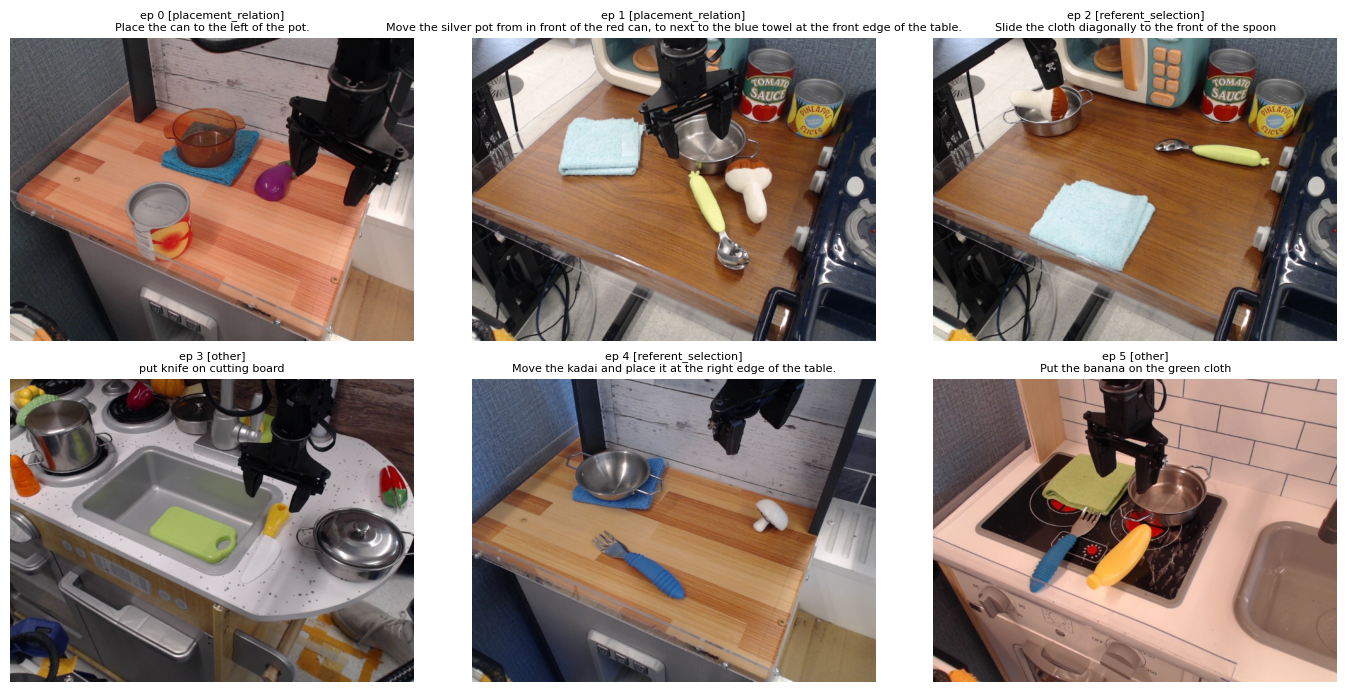

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
rows = load_manifest(CACHE_DIR)
print(f'{len(rows)} cached scenes')

# Category mix, so the referent_selection yield is visible before probing.
# Reads category_manual when set (manual correction), falling back to the
# heuristic category, matching the convention downstream code follows.
from collections import Counter
effective_category = [r['category_manual'] or r['category'] for r in rows]
print('categories:', dict(Counter(effective_category)))

with_grasp = sum(1 for r in rows if r['grasp_image_path'])
print(f'{with_grasp}/{len(rows)} cached scenes have a grasp-frame PNG')

show = rows[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, row in zip(axes.ravel(), show):
    img = Image.open(os.path.join(CACHE_DIR, row['image_path']))
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"ep {row['episode_index']} [{row['category']}]\n{row['instruction']}",
                 fontsize=8)
for ax in axes.ravel()[len(show):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 8. Manual feasibility review

Antonym-swapped contrastive prompts can imply physically infeasible placements
(for example "move the cloth to the right of the colander" when there is no
space on the right). Feasibility labeling is an iterative process and lives in
a dedicated notebook so caching and review stay separate.


In [11]:
# Labels are written only from Notebook 02b. This cell reports current counts
# so a cache session can see review headroom without opening 02b.
from collections import Counter
reviewed = load_manifest(CACHE_DIR)
print('feasible_both:', dict(Counter(r['feasible_both'] for r in reviewed)))
print('Open 02b_scene_review.ipynb for iterative feasibility review.')


feasible_both: {'unreviewed': 224}
Open 02b_scene_review.ipynb for iterative feasibility review.


## 9. Automated duplicate-target proposal

The contrastive probe is a clean referent test only when a scene contains two or
more instances of the same object, so an antonym-swapped instruction names a
distinct, real target on both sides. A single target among different-type
distractors makes the swapped instruction unsatisfiable.

This section proposes the `duplicate_target` label automatically with an
open-vocabulary detector (OWLv2): for each `referent_selection` scene the target
noun is extracted from the instruction, its instances are counted in the cached
frame, and the second-highest detection score decides `yes`, `no`, or `unclear`.
High-confidence proposals are accepted; `unclear` scenes are left for
confirmation in Notebook 02b. The pass writes back through the manifest, so it is
restart-safe and only touches scenes still `unreviewed` for `duplicate_target`.


In [12]:
import importlib

import detect_duplicates
importlib.reload(detect_duplicates)
from detect_duplicates import run_auto_pass
from data import CATEGORY_REFERENT, review_summary

# Set a small limit first to sanity-check the detector, then remove it to label
# the full candidate set. Thresholds default to the values in detect_duplicates.
summary = run_auto_pass(
    CACHE_DIR,
    categories=(CATEGORY_REFERENT,),
    only_pairable=True,
    limit=None,
)
print('auto-pass proposals:', summary)

rev = review_summary(CACHE_DIR)
print(f"primary_eligible (referent, feasible_both=yes, duplicate_target=yes): "
      f"{rev['primary_eligible']}")
print(f"duplicate_target awaiting confirmation (unclear): "
      f"{rev['referent_pairable_dup_unclear']}")
print(f"duplicate_target still unreviewed: "
      f"{rev['referent_pairable_dup_unreviewed']}")
print(f"duplicate_source breakdown: {rev['duplicate_source']}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:99: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/620M [00:00<?, ?B/s]

[update_manifest_annotations] updated 30 rows in /content/drive/MyDrive/openvla_cache/bridge_multiobj/manifest.csv
[run_auto_pass] 30 scenes -> yes=0 no=28 unclear=2 (noun_failures=0)
auto-pass proposals: {'total': 30, 'yes': 0, 'no': 28, 'unclear': 2, 'noun_failures': 0, 'thresholds': {'score_thresh': 0.1, 'high': 0.3, 'low': 0.15}}
primary_eligible (referent, feasible_both=yes, duplicate_target=yes): 0
duplicate_target awaiting confirmation (unclear): 2
duplicate_target still unreviewed: 0
duplicate_source breakdown: {'auto': 30}
